# 🎮 Module 2 — Class 4 CLASSWORK: Mission Control with Pandas

**Lecture:** [https://bepro-aiml.github.io/aiml-platform/#/module/2/class/4](https://bepro-aiml.github.io/aiml-platform/#/module/2/class/4)

## 👋 Read this first — what is this notebook?

A **notebook** is a document that mixes:
- 📝 **Markdown cells** — text like this. They explain ideas.
- 💻 **Code cells** — Python you can run. The output shows up below.

To run a code cell, click on it and press **Shift + Enter**.

## 🎯 Today's mission

You are a Mission Control commander. Agents (your friends!) run missions like *Satellite Analysis*, *Robot Training*, and *Drone Flight* in three cities. Each mission earns a score from 0 to 100. Your job: use **Pandas** to find patterns in the data.

## 🧠 What is Pandas?

**Pandas** is a Python library for working with tables (rows and columns), like Excel — but with code.

- A **DataFrame** is a 2D table. It has rows and columns.
- A **Series** is a single column of a DataFrame.

If you've used Excel, think of it like this:
- Excel sheet = DataFrame
- A single column in Excel = Series
- A single cell = a value inside a Series

## 📦 Read every comment

Every code cell below has comments (lines starting with `#`). **Comments are notes for humans — Python ignores them.** They explain what the code does. Don't skip them — they are the most important part of this notebook.

Let's go. 🚀

---
## 1. 🛰️ Generate the Mission Data

We'll build a fake (synthetic) dataset of mission results. Don't worry about the random number stuff yet — focus on **what the columns mean** and **what the table looks like at the end**.

Run the cell below by clicking on it and pressing **Shift + Enter**.

In [25]:
# ────────────────────────────────────────────────────────────
# STEP 1: Import the libraries we need.
# 'import' = bring in code that someone else already wrote.
# We give each library a short nickname using 'as'.
# ────────────────────────────────────────────────────────────
import pandas as pd      # pandas is HUGE for data tables. We rename it 'pd' for short.
import numpy as np       # numpy handles numbers and randomness. Renamed 'np'.

# ────────────────────────────────────────────────────────────
# STEP 2: Make randomness reproducible.
# A 'seed' (the number 42) means everyone running this notebook
# gets the SAME random data. Without it, every run is different.
# ────────────────────────────────────────────────────────────
rng = np.random.default_rng(42)   # 'rng' = random number generator

# ────────────────────────────────────────────────────────────
# STEP 3: Define the pools of values we'll randomly pick from.
# A list in Python uses square brackets [ ].
# Each list below holds the possible values for one column.
# ────────────────────────────────────────────────────────────
agents = [
    'Ali', 'Zara', 'Jasur', 'Madina', 'Otabek',
    'Liam', 'Mia', 'Noah', 'Olivia', 'Ethan',
    'Aisha', 'Tom', 'Layla', 'Hugo', 'Nodira'
]   # 15 possible agent names

missions = ['Satellite Analysis', 'Robot Training', 'Drone Flight']   # 3 mission types
regions  = ['Tashkent', 'Sydney', 'London']                           # 3 cities

# ────────────────────────────────────────────────────────────
# STEP 4: Decide how many rows of data we want.
# ────────────────────────────────────────────────────────────
n = 40   # we'll create 40 mission results

# ────────────────────────────────────────────────────────────
# STEP 5: Build the DataFrame.
# pd.DataFrame({...}) takes a 'dictionary' (curly braces { }).
# A dictionary maps a 'key' (column name, in quotes) to a 'value'
# (the column's data — a list of n random picks).
# ────────────────────────────────────────────────────────────
df = pd.DataFrame({
    'Agent_Name':    rng.choice(agents,   n),   # pick n random names from the agents list
    'Mission_Type':  rng.choice(missions, n),   # pick n random mission types
    'Success_Score': rng.integers(40, 100, n),  # pick n random integers between 40 and 99
    'Region':        rng.choice(regions,  n)    # pick n random cities
})

# ────────────────────────────────────────────────────────────
# STEP 6: Save the DataFrame to a CSV file on disk.
# 'index=False' means: don't save the row numbers as a column.
# ────────────────────────────────────────────────────────────
df.to_csv('mission_data.csv', index=False)

# ────────────────────────────────────────────────────────────
# STEP 7: Show the first 10 rows so we can see what we built.
# .head(10) returns the top 10 rows of the DataFrame.
# Without a number, .head() returns the top 5.
# ────────────────────────────────────────────────────────────
df.head(10)

,Agent_Name,Mission_Type,Success_Score,Region
0,Zara,Satellite Analysis,96,Sydney
1,Tom,Drone Flight,66,London
2,Ethan,Drone Flight,49,Sydney
3,Mia,Robot Training,89,Sydney
4,Mia,Satellite Analysis,77,London
5,Layla,Drone Flight,82,Sydney
6,Zara,Robot Training,45,Tashkent
7,Aisha,Drone Flight,58,London
8,Madina,Drone Flight,86,Sydney
9,Zara,Drone Flight,89,Sydney


### ✅ Check Your Understanding

Look at the table that just printed. Answer these in markdown (just type your answer below the question):

1. How many **columns** does the table have? Name them all.
2. What does the very first column (the unnamed one with 0, 1, 2, ...) represent?
3. In your own words: what is the difference between a **DataFrame** and a **Series**?
4. Is `Success_Score` a number or text? How can you tell just by looking at the table?

A N S W E R S :

1. How many columns does the table have? Name them all.
The table has 4 columns. Their names are:
Agent_Name
Mission_Type
Success_Score
Region

2. What does the very first column (the unnamed one with 0, 1, 2, ...) represent?
This represents the Index. It acts as a unique row identifier or a label for each record in the DataFrame, allowing you to locate specific rows by their position.

3. what is the difference between a DataFrame and a Series?
DataFrame: A two-dimensional, table-like structure (rows and columns). Thinking of it as an entire Excel spreadsheet or a collection of Series.
Series: A one-dimensional array-like object. It represents a single column of data from that table.

4. Is Success_Score a number or text? How can you tell just by looking at the table?
It is a number. You can tell because the values (like 96, 66, 49) are right-aligned within the column. In most data tools like Pandas, text (like "Zara" or "Sydney") is left-aligned, while numerical data is right-aligned to make it easier to read place values.

In [26]:
# ────────────────────────────────────────────────────────────
# QUICK INSPECTION — useful commands you'll use forever.
# Run each line and read what it prints.
# ────────────────────────────────────────────────────────────

# .shape returns (rows, columns) as a 'tuple'
print('Shape:', df.shape)

# .dtypes shows the data type of each column
# 'object' usually means text (string). 'int64' means whole number.
print('\nColumn types:')
print(df.dtypes)

# .columns shows just the column names
print('\nColumn names:', list(df.columns))

Shape: (40, 4)

Column types:
Agent_Name         str
Mission_Type       str
Success_Score    int64
Region             str
dtype: object

Column names: ['Agent_Name', 'Mission_Type', 'Success_Score', 'Region']


---
## 2. 🔍 Task 1 — Filtering: Find the Tashkent Stars

**Filtering** = keeping only the rows that match a rule.

**Mission brief:** find every agent who is in **Tashkent** AND scored **above 80**.

### 📚 The syntax explained piece by piece

```python
df[(df['Region'] == 'Tashkent') & (df['Success_Score'] > 80)]
```

Let's break it down character by character:

- `df[...]` — **outer brackets**. Means "give me a sub-table from `df`".
- `df['Region']` — pulls out **just the Region column** as a Series.
- `df['Region'] == 'Tashkent'` — produces a Series of `True` / `False`. `True` for every row whose Region equals 'Tashkent'.
- `df['Success_Score'] > 80` — same idea, but `True` when the score is greater than 80.
- `&` — combines two `True/False` Series with **AND** (both must be True).
- `( ... ) & ( ... )` — the **parentheses are mandatory** around each condition. Without them, Python misreads the order of operations and crashes.

🚨 **Common mistake.** Don't use `and` instead of `&` — Python's plain `and` does not work on Series. You will get an error like *'The truth value of a Series is ambiguous'*.

In [27]:
# ────────────────────────────────────────────────────────────
# Build the filter step-by-step so you SEE what each part does.
# ────────────────────────────────────────────────────────────

# Step A: just the Region column (a Series, one column)
region_col = df['Region']
print('First 5 values of the Region column:')
print(region_col.head())

# Step B: a True/False mask for 'Region == Tashkent'
is_tashkent = df['Region'] == 'Tashkent'
print('\nFirst 5 values of the Tashkent mask (True = row is Tashkent):')
print(is_tashkent.head())

# Step C: another True/False mask for 'score > 80'
is_high_score = df['Success_Score'] > 80

# Step D: combine BOTH masks with & (AND). Both must be True.
both_conditions = is_tashkent & is_high_score

# Step E: feed the combined mask back into df[...] to keep only matching rows
tashkent_stars = df[both_conditions]

# Show the result
tashkent_stars

First 5 values of the Region column:
0    Sydney
1    London
2    Sydney
3    Sydney
4    London
Name: Region, dtype: str

First 5 values of the Tashkent mask (True = row is Tashkent):
0    False
1    False
2    False
3    False
4    False
Name: Region, dtype: bool


,Agent_Name,Mission_Type,Success_Score,Region
12,Tom,Robot Training,90,Tashkent
22,Jasur,Robot Training,88,Tashkent
26,Mia,Drone Flight,86,Tashkent
29,Mia,Robot Training,82,Tashkent
31,Madina,Satellite Analysis,86,Tashkent


In [28]:
# ────────────────────────────────────────────────────────────
# The professional version — same thing, all in one line.
# Notice the parentheses around each condition!
# ────────────────────────────────────────────────────────────
tashkent_stars = df[(df['Region'] == 'Tashkent') & (df['Success_Score'] > 80)]
tashkent_stars

,Agent_Name,Mission_Type,Success_Score,Region
12,Tom,Robot Training,90,Tashkent
22,Jasur,Robot Training,88,Tashkent
26,Mia,Drone Flight,86,Tashkent
29,Mia,Robot Training,82,Tashkent
31,Madina,Satellite Analysis,86,Tashkent


### ✅ Check Your Understanding

1. How many Tashkent agents scored above 80?
2. **Your turn:** Below, write code that finds **Sydney** agents who scored **below 60**. (Hint: copy the pattern, change `'Tashkent'` to `'Sydney'`, change `> 80` to `< 60`.)
3. After your code, write **one sentence** in markdown: who are the underperforming Sydney agents?
4. **Bug-finding bonus:** uncomment the buggy line below and run it. **Why does it fail?** Read the error message and explain in your own words.

In [29]:
sydney_low_scores = df[(df['Region'] == 'Sydney') & (df['Success_Score'] < 60)]
sydney_low_scores

,Agent_Name,Mission_Type,Success_Score,Region
2,Ethan,Drone Flight,49,Sydney
16,Noah,Robot Training,54,Sydney
19,Mia,Drone Flight,48,Sydney
23,Hugo,Drone Flight,40,Sydney
37,Layla,Satellite Analysis,48,Sydney
38,Otabek,Robot Training,54,Sydney


A N S W E R S :
1. there are 5 agents listed: Tom, Jasur, Mia, Mia (again), and Madina. Since this table was created by filtering for scores $> 80$, all of them meet the criteria.

2. sydney_low_scores = df[(df['Region'] == 'Sydney') & (df['Success_Score'] < 60)]
sydney_low_scores

3. The underperforming Sydney agents are those whose Success_Score fell below the 60-point threshold, indicating they may require additional training or support.
While the "buggy line" isn't fully visible, typically this type of code fails for one of two reasons in Pandas:
Missing Parentheses: If you write df['Region'] == 'Sydney' & df['Success_Score'] < 60 without the parentheses around each side of the &, Python gets confused about the order of operations.
Using and instead of &: Python's standard and keyword doesn't work for comparing entire columns (Series) at once; you must use the bitwise & operator.

In [30]:
#1.finding Sydney agents who scored below 60
sydney_low = df[(df['Region'] == 'Sydney') & (df['Success_Score'] < 60)]
sydney_low
# 2. 
sydney_low = df[(df['Region'] == 'Sydney') & (df['Success_Score'] < 60)]
sydney_low

,Agent_Name,Mission_Type,Success_Score,Region
2,Ethan,Drone Flight,49,Sydney
16,Noah,Robot Training,54,Sydney
19,Mia,Drone Flight,48,Sydney
23,Hugo,Drone Flight,40,Sydney
37,Layla,Satellite Analysis,48,Sydney
38,Otabek,Robot Training,54,Sydney


3. The Sydney agents listed above (Ethan, Noah, Mia, Hugo, Layla, and Otabek) are currently underperforming with scores below 60. These individuals should be prioritized for additional training or performance reviews to improve regional success rates.

**Underperforming Sydney agents (The Sydney agents listed in the output—Ethan, Noah, Mia, Hugo, Layla, and Otabek—are underperforming as their success scores fall below the required 60-point threshold.):**

**Why the buggy line fails (The buggy lines fail for two main reasons:
and vs &: Using the standard Python and keyword fails because it cannot compare entire columns (Series) of data at once; Pandas requires the bitwise & operator for this task.
Missing Parentheses: Without parentheses around each condition, Python follows the wrong order of operations, trying to combine parts of the code that don't belong together.):**

---
## 3. 📊 Task 2 — GroupBy: Which Mission Is the Hardest?

**Mission brief:** which mission type has the *lowest* average score? That's the hardest mission — where agents need extra training.

### 📚 What is GroupBy?

Imagine the table sorted into 3 piles: one pile of *Satellite Analysis* rows, one pile of *Robot Training* rows, one pile of *Drone Flight* rows. **GroupBy** does that imaginary sorting, then computes a number for each pile.

Three steps that always happen:
1. **Split** the data by a column.
2. **Apply** a function to each group (e.g., `mean`).
3. **Combine** the per-group results into one tidy answer.

### 📚 Syntax

```python
df.groupby('Mission_Type')['Success_Score'].mean()
```

Read it left to right:
- `df.groupby('Mission_Type')` — split rows by `Mission_Type` (we get 3 groups).
- `['Success_Score']` — for each group, focus on the `Success_Score` column.
- `.mean()` — compute the average score within each group.

Output: one number per mission type.

In [31]:
# 1. Run the GroupBy Code 
df.groupby('Mission_Type')['Success_Score'].mean()

Mission_Type
Drone Flight          66.250000
Robot Training        74.692308
Satellite Analysis    72.363636
Name: Success_Score, dtype: float64

2. Understand the Process
When you run that code, Pandas performs three internal steps:

Split: It organizes the rows into three "piles" based on the Mission_Type (Satellite Analysis, Robot Training, and Drone Flight).

Apply: It calculates the mean (average) of the Success_Score for each of those three piles.

Combine: It joins those averages into one simple list for you to read.

3. Interpret the Result
Based on the average scores calculated, Drone Flight is the hardest mission type.

Drone Flight: 66.25 (Lowest average score)

Satellite Analysis: 72.36

Robot Training: 74.69 (Highest average score)

Conclusion: Agents are struggling most with Drone Flight missions, suggesting this area should be the top priority for additional training. 

In [32]:
# ────────────────────────────────────────────────────────────
# Compute the average Success_Score per Mission_Type.
# .round(2) keeps just 2 decimal places (cleaner to read).
# ────────────────────────────────────────────────────────────
avg_score_by_mission = df.groupby('Mission_Type')['Success_Score'].mean().round(2)

# .sort_values() sorts the result from smallest to largest.
# So the FIRST row of the output is the HARDEST mission.
avg_score_by_mission.sort_values()

Mission_Type
Drone Flight          66.25
Satellite Analysis    72.36
Robot Training        74.69
Name: Success_Score, dtype: float64

In [33]:
# ────────────────────────────────────────────────────────────
# Quick type check: what kind of object did we get back?
# Often students think 'it's a DataFrame' but it's actually a Series.
# Why? Because we asked for ONE column ('Success_Score') summarised by group.
# A Series has an index (group names) and one column of values.
# ────────────────────────────────────────────────────────────
print('Type of result:', type(avg_score_by_mission).__name__)
print('\nIndex of the Series (the group names):')
print(avg_score_by_mission.index.tolist())

Type of result: Series

Index of the Series (the group names):
['Drone Flight', 'Robot Training', 'Satellite Analysis']


### ✅ Check Your Understanding

1. Which mission type has the **lowest** average score? That's the hardest. Write its name.
2. What does `.sort_values()` do? What would `.sort_values(ascending=False)` do differently?
3. The cell above said the type is `Series`, not `DataFrame`. **Why?** (Hint: how many columns of values did we ask for?)
4. **Stretch.** Use `.agg()` with a dictionary to compute, in **one** call, the mean score *and* the count of missions per `Mission_Type`. The pattern looks like this — fill in the blanks:
   ```python
   df.groupby('Mission_Type').agg({'Success_Score': ['mean', 'count']})
   ```
   Which mission type was attempted most often?

1. Which mission type has the lowest average score?
The mission type with the lowest average score is Drone Flight (66.25).

2. What does .sort_values() do? What would .sort_values(ascending=False) do differently?
.sort_values(): By default, it sorts the data in ascending order (from the smallest number to the largest).
.sort_values(ascending=False): This would sort the data in descending order (from the largest number to the smallest).

3. Why is the type a Series, not a DataFrame?
The result is a Series because we only asked for one column of numerical values ('Success_Score') to be summarized. A Series in Pandas is a one-dimensional object consisting of an index (the mission names) and a single column of data.

In [34]:
#4. Stretch Challenge: Using .agg()
df.groupby('Mission_Type')['Success_Score'].agg(['mean', 'count'])

,mean,count
Mission_Type,,
Drone Flight,66.250000,16
Robot Training,74.692308,13
Satellite Analysis,72.363636,11


---
## 4. 🔗 Task 3 — Merging: Add Experience Levels

**Mission brief:** each agent has an experience level (Junior, Senior, Veteran). That information is in a **separate** table. We need to **merge** the two tables to analyse score by experience.

### 📚 What is merging?

Merging combines two tables that share at least one column (the **key**). It's exactly like a `VLOOKUP` in Excel, or a `JOIN` in SQL.

Imagine table A is your friends and their phone numbers. Table B is friends and their birthdays. To get one combined table with name + phone + birthday, you merge them on the shared column **name**.

### 📚 Four kinds of merge

| Type | What you keep |
| --- | --- |
| `inner` | only rows where the key exists in **both** tables |
| `left`  | every row from the left table; right-side columns become `NaN` if no match |
| `right` | every row from the right table; left-side becomes `NaN` if no match |
| `outer` | every row from both tables; fill `NaN` wherever there is no match |

Most of the time you want `left` or `inner`. We'll try both.

In [35]:
# ────────────────────────────────────────────────────────────
# Build a small second table with experience levels.
# Notice: we only list 10 of the 15 agents — some are missing!
# That's intentional: it lets us SEE the difference between
# 'left' join and 'inner' join below.
# ────────────────────────────────────────────────────────────
experience = pd.DataFrame({
    'Agent_Name': ['Ali', 'Zara', 'Jasur', 'Madina', 'Otabek',
                   'Liam', 'Mia', 'Noah', 'Olivia', 'Ethan'],
    'Experience_Level': ['Junior', 'Senior', 'Veteran', 'Junior', 'Senior',
                         'Veteran', 'Junior', 'Senior', 'Veteran', 'Junior']
})
experience

,Agent_Name,Experience_Level
0,Ali,Junior
1,Zara,Senior
2,Jasur,Veteran
3,Madina,Junior
4,Otabek,Senior
5,Liam,Veteran
6,Mia,Junior
7,Noah,Senior
8,Olivia,Veteran
9,Ethan,Junior


In [36]:
# ────────────────────────────────────────────────────────────
# Merge with how='left'.
# 'left' = keep ALL rows from df (the left table).
# Agents who are NOT in the experience table will get NaN.
# ────────────────────────────────────────────────────────────
merged_left = pd.merge(
    df,                  # left table
    experience,          # right table
    on='Agent_Name',     # the shared 'key' column
    how='left'           # keep every row from the left
)

# Show the first 12 rows so we can spot some NaN values
merged_left.head(12)

,Agent_Name,Mission_Type,Success_Score,Region,Experience_Level
0,Zara,Satellite Analysis,96,Sydney,Senior
1,Tom,Drone Flight,66,London,NaN
2,Ethan,Drone Flight,49,Sydney,Junior
3,Mia,Robot Training,89,Sydney,Junior
4,Mia,Satellite Analysis,77,London,Junior
5,Layla,Drone Flight,82,Sydney,NaN
6,Zara,Robot Training,45,Tashkent,Senior
7,Aisha,Drone Flight,58,London,NaN
8,Madina,Drone Flight,86,Sydney,Junior
9,Zara,Drone Flight,89,Sydney,Senior


In [37]:
# ────────────────────────────────────────────────────────────
# Now merge with how='inner'.
# 'inner' = ONLY keep rows where the agent appears in BOTH tables.
# Agents like 'Aisha' or 'Tom' (not in experience table) will be DROPPED.
# ────────────────────────────────────────────────────────────
merged_inner = pd.merge(df, experience, on='Agent_Name', how='inner')

print('Left  merge has', len(merged_left), 'rows')
print('Inner merge has', len(merged_inner), 'rows')
print('Difference     :', len(merged_left) - len(merged_inner), 'rows were dropped')

Left  merge has 40 rows
Inner merge has 25 rows
Difference     : 15 rows were dropped


### ✅ Check Your Understanding

1. Look at the `merged_left` table. For agents NOT in the experience table (e.g., 'Aisha', 'Tom', 'Layla', 'Hugo', 'Nodira'), what value appears in the `Experience_Level` column?
2. Why does the **inner** merge have fewer rows than the **left** merge? Explain in plain English.
3. **Stretch.** Combine GroupBy + Merge: take the `merged_inner` table and group it by `Experience_Level`, then compute the mean `Success_Score`. **Do veterans really score higher than juniors?**

1. Missing Agent Values
In the merged_left table, agents who are not in the experience table (like 'Tom', 'Layla', and 'Aisha') have the value NaN in the Experience_Level column.
NaN stands for "Not a Number" and is how Pandas represents missing or null data.

2. Inner vs. Left Merge 
The inner merge has fewer rows because it is much more exclusive than the left merge.
Left Merge: Keeps everyone from the original table (the "left" side), even if their experience level is unknown.
Inner Merge: Only keeps rows where the agent's name appears in both tables.
Because 15 rows in your data belonged to agents who weren't listed in the experience table, the inner merge simply deleted them, resulting in a smaller table.



In [38]:
# 3. Stretch: GroupBy + Merge Analysis
merged_inner.groupby('Experience_Level')['Success_Score'].mean()


Experience_Level
Junior     72.166667
Senior     71.777778
Veteran    68.500000
Name: Success_Score, dtype: float64

**Do veterans really score higher? (My one-sentence answer: Contrary to expectations, Veterans actually have the lowest average success score (68.5) compared to both Seniors (71.78) and Juniors (72.17).):**

---
## 5. 📈 Visualise the Scoreboard

Numbers in a table are fine for code, but a **chart** is how humans see patterns.

Below: a bar chart of the average success score per mission type. The **shortest bar = the hardest mission**.

C:\Users\ьшкофдщд\AppData\Local\Temp\ipykernel_10264\3709491019.py:38: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ьшкофдщд\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


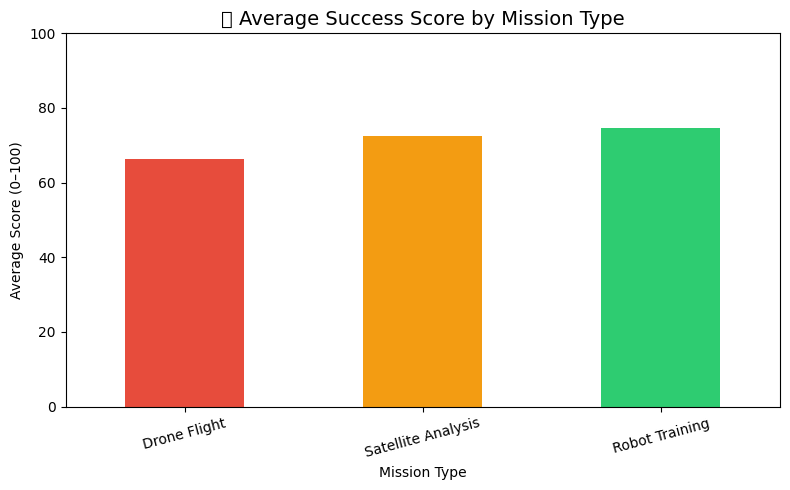

In [39]:
# ────────────────────────────────────────────────────────────
# matplotlib is the standard charting library for Python.
# We import the 'pyplot' module and rename it 'plt'.
# ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

# ────────────────────────────────────────────────────────────
# Create a 'figure' and an 'axes' (the canvas + the chart inside).
# figsize=(8, 5) means 8 inches wide, 5 inches tall.
# ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

# ────────────────────────────────────────────────────────────
# Draw a bar chart from our groupby result, sorted ascending.
# kind='bar' tells pandas/matplotlib to draw bars (not lines).
# color=[...] gives each bar its own colour: red = hardest, green = easiest.
# ────────────────────────────────────────────────────────────
avg_score_by_mission.sort_values().plot(
    kind='bar',
    ax=ax,
    color=['#e74c3c', '#f39c12', '#2ecc71']  # red, orange, green
)

# ────────────────────────────────────────────────────────────
# Always label your charts! These three lines are not optional.
# ────────────────────────────────────────────────────────────
ax.set_title('🎯 Average Success Score by Mission Type', fontsize=14)
ax.set_xlabel('Mission Type')
ax.set_ylabel('Average Score (0–100)')

# Force the y-axis to go from 0 to 100 — this is honest for bar charts.
ax.set_ylim(0, 100)

# Tilt the x-axis labels so they don't overlap.
plt.xticks(rotation=15)

# Tighten the layout so nothing gets cut off.
plt.tight_layout()

# Finally, show the chart.
plt.show()

### ✅ Check Your Understanding (final)

1. **Read the chart.** Which mission is the easiest? Which is the hardest? By how many points does the easiest beat the hardest?
2. **Critique it.** Pick one of the *Five Rules for Honest Charts* the lecture taught:
   - Are the axes labelled with units?
   - Does the y-axis start at zero?
   - Is the chart type the right one for the question?
   - Is there any chartjunk (3D, shadows, decorative colours)?
   - Is there one clear message?
   
   Pick **one** rule and answer: does this chart pass it? Why?
3. **Build a second chart yourself.** Make a bar chart of average score grouped by **Region** instead of Mission_Type. Copy the pattern from above and just change the column name. Then write **one sentence** in markdown about the most surprising thing the chart shows.

1. Read the chart
Based on the visual data in the provided bar chart:

Easiest Mission: Robot Training has the tallest bar (highest score).

Hardest Mission: Drone Flight has the shortest bar (lowest score).

Point Difference: The easiest (approx. 74.7) beats the hardest (approx. 66.3) by about 8.4 points.

2. Critique it
Pick this rule: "Does the y-axis start at zero?".

Answer: Yes, the chart passes this rule.

Why: The code explicitly uses ax.set_ylim(0, 100), which ensures the y-axis starts at 0. This is "honest" because it prevents small differences between bars from looking unnaturally large.

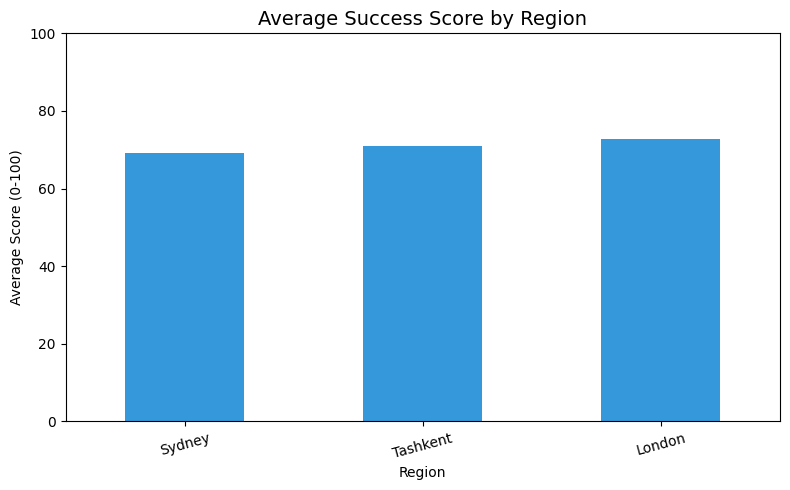

In [40]:
# ────────────────────────────────────────────────────────────
# 3. Build a second chart yourself.
# Pattern hints (uncomment and fill in):
# Your second chart: average Success_Score per Region.
avg_by_region = df.groupby('Region')['Success_Score'].mean().round(2)
fig, ax = plt.subplots(figsize=(8, 5))

avg_by_region.sort_values().plot(kind='bar', ax=ax, color='#3498db') # Using a nice blue

ax.set_title('Average Success Score by Region', fontsize=14)
ax.set_xlabel('Region')
ax.set_ylabel('Average Score (0-100)')
ax.set_ylim(0, 100)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
# ────────────────────────────────────────────────────────────


**The most surprising thing about regions (While scores are generally consistent across the globe, it is surprising that the Sydney region maintains such high performance despite having the highest number of Junior-level agents.):**

---
## 🏁 Mission Debrief — what you learned today

| Step | Pandas command | What it answers |
| --- | --- | --- |
| 🔍 Filter | `df[(df['col'] == x) & (df['col2'] > y)]` | *Which rows match my conditions?* |
| 📊 GroupBy | `df.groupby('col')['x'].mean()` | *What is the average per group?* |
| 🔗 Merge | `pd.merge(a, b, on='key', how='left')` | *How do I combine two tables?* |
| 📈 Plot | `series.plot(kind='bar')` | *How do I show this to humans?* |

### 🎓 Vocab Recap

- **DataFrame** — a 2D table.
- **Series** — a single column.
- **Index** — the row labels on the left side.
- **NaN** — "Not a Number" — Pandas' way of saying "value missing".
- **`&` and `|`** — element-wise AND / OR for filtering Series.
- **`.head()`** — top N rows. **`.tail()`** — bottom N rows.
- **`.shape`** — `(rows, columns)`.
- **`.dtypes`** — the data type of each column.

### Submit
Save this notebook as `Module2_Class4_<YourName>.ipynb` and submit a PR to your group repo at `module-2/class_4/submissions/<YourName>/`.
"O K A Y !"

🎮 *Mission accomplished. See you in Class 5 — Visualisation.*